# `sampled_ncd` Diagnosis — Bible Corpus

Focuses on understanding the symmetric `normalized_compression_distance` metric:
- **What NCD values look like** for close vs. distant language pairs
- **How sample size affects sensitivity** — at what byte budget each compressor best discriminates domain distance
- **Compressor comparison**: zlib (window 32 KB), bz2 (block 900 KB), lzma (very large context)

Only the symmetric variant is used: `NCD_sym = (mean(C(ab), C(ba)) - min(C(a), C(b))) / max(C(a), C(b))`

In [10]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from itertools import combinations
import pickle
import bz2
import lzma
import urllib.request
import xml.etree.ElementTree as ET
from functools import partial
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from corpus_helpers.read import lower, split_line, delete_newline, split_word, delete_blank, as_bytes, chain_preprocessors
from corpus_helpers.metrics import normalized_compression_distance, sampled_distance

## 1. Download & parse (same setup as `bible_domain_distance.ipynb`)

In [2]:
LANGUAGES = {
    'en': 'English',
    'de': 'German',
    'nl': 'Dutch',
    'da': 'Danish',
    'sv': 'Swedish',
    'cs': 'Czech',
    'sk': 'Slovak',
    'pl': 'Polish',
    'hr': 'Croatian',
}

RAW_BASE = 'https://raw.githubusercontent.com/christos-c/bible-corpus/master/bibles'
CACHE_DIR = Path('_bible_cache')
CACHE_DIR.mkdir(exist_ok=True)

def download(lang_code: str, lang_name: str) -> Path:
    dest = CACHE_DIR / f'{lang_code}.xml'
    if not dest.exists():
        url = f'{RAW_BASE}/{lang_name}.xml'
        print(f'Downloading {lang_name}...', end=' ', flush=True)
        urllib.request.urlretrieve(url, dest)
        print('done')
    else:
        print(f'{lang_name}: cached')
    return dest

PRETOKEN_PIPELINE = [lower, split_line, delete_newline, split_word, delete_blank, as_bytes]

def parse_bible(path: Path) -> list[bytes]:
    tree = ET.parse(path)
    segments = [(seg.text or '').strip() for seg in tree.iter('seg')
                if seg.text and seg.text.strip()]
    return chain_preprocessors(segments, PRETOKEN_PIPELINE)

paths = {code: download(code, name) for code, name in LANGUAGES.items()}
corpora: dict[str, list[bytes]] = {}
for code, path in paths.items():
    corpora[code] = parse_bible(path)
    total_bytes = sum(len(d) for d in corpora[code])
    print(f'{code}: {len(corpora[code]):,} words, {total_bytes/1e6:.1f} MB')

English: cached
German: cached
Dutch: cached
Danish: cached
Swedish: cached
Czech: cached
Slovak: cached
Polish: cached
Croatian: cached
en: 918,445 words, 3.3 MB
de: 820,005 words, 3.4 MB
nl: 839,790 words, 3.3 MB
da: 786,197 words, 3.0 MB
sv: 860,278 words, 3.5 MB
cs: 731,091 words, 3.3 MB
sk: 746,897 words, 3.3 MB
pl: 741,355 words, 3.4 MB
hr: 697,515 words, 2.8 MB


## 2. Compressor definitions

We compare three compressors with very different internal buffer / context sizes:

| Compressor | Typical window | Notes |
|-----------|---------------|-------|
| `zlib`    | 32 KB         | Default level 6 |
| `bz2`     | 900 KB block  | Block-based, no long-range context |
| `lzma`    | Up to 64 MB   | Dictionary-based, longest context |

The hypothesis is that **lzma needs larger inputs** before its context advantage materialises, while **zlib saturates at smaller sizes**.

In [3]:
COMPRESSORS = {
    'zlib':  None,                           # default in normalized_compression_distance
    'bz2':   bz2.compress,
    'lzma':  lzma.compress,
}

def ncd_sym(compressor):
    """Return a symmetric NCD callable suitable for sampled_distance."""
    return partial(normalized_compression_distance, compressor=compressor, symmetric=True)

## 3. Sample-size sweep — all pairs

For each compressor, sweep `SAMPLE_SIZES` over all C(9,2) = 36 unordered pairs (no diagonal).
The resulting `sweep` dict is used in §4 to build NCD matrices for the URIEL correlation.

In [11]:
SAMPLE_SIZES = [2 ** i for i in range(8, 22, 2)]
LANG_CODES = list(LANGUAGES.keys())
N = len(LANG_CODES)
pairs_idx = list(combinations(range(N), 2))
SAMPLE_SIZES

[256, 1024, 4096, 16384, 65536, 262144, 1048576]

In [ ]:
sweep: dict[str, dict[tuple, list]] = {}
# sweep[comp_name][(i, j)] = list of (sample_size, mean, std)

for comp_name, comp_fn in COMPRESSORS.items():
    metric = ncd_sym(comp_fn)
    sweep[comp_name] = {(i, j): [] for i, j in pairs_idx}
    for sz in SAMPLE_SIZES:
        for i, j in pairs_idx:
            src, tgt = LANG_CODES[i], LANG_CODES[j]
            print(f'[{comp_name}  sz={sz:>7,}]  {src} ↔ {tgt}...', end=' ', flush=True)
            res = sampled_distance(
                corpora[src], corpora[tgt], metric,
                sample_size_per_iteration=sz,
                k=10, threshold=0.001, max_iterations=100,
                seed=42, show_progress=True,
            )
            sweep[comp_name][(i, j)].append((sz, res['mean'], res['std']))
            print(f'NCD={res["mean"]:.4f}  std={res["std"]:.4f}  converged={res["converged"]}')

with open('_bible_cache/sweep_ncd.pkl', 'wb') as f: 
    pickle.dump(sweep, f)

In [6]:
sweep_path = Path('_bible_cache/sweep_ncd.pkl')

if sweep_path.exists(): 
    with sweep_path.open('rb') as f:
        sweep = pickle.load(f)
else: 
    print('could not find the sweep pickle, run the cell above')

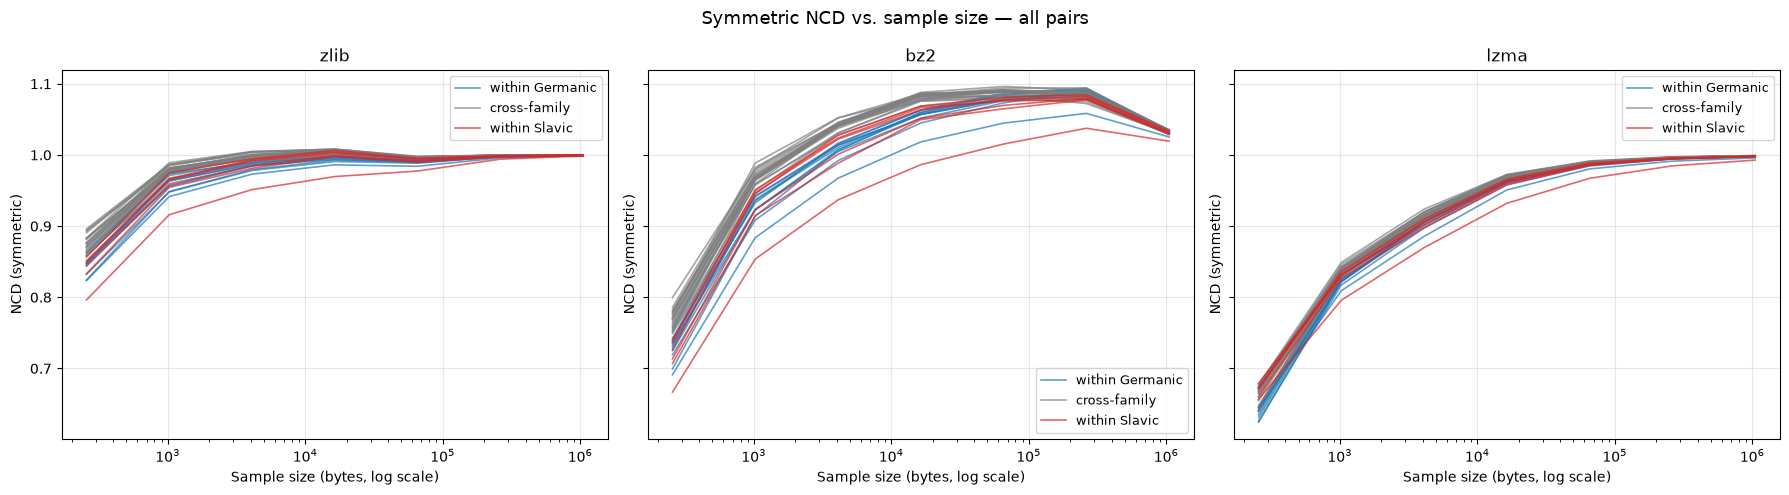

In [7]:
GERMANIC = {'en', 'de', 'nl', 'da', 'sv'}
SLAVIC   = {'cs', 'sk', 'pl', 'hr'}

def pair_group(i, j):
    a, b = LANG_CODES[i], LANG_CODES[j]
    if {a, b} <= GERMANIC: return 'within Germanic', 'tab:blue'
    if {a, b} <= SLAVIC:   return 'within Slavic',   'tab:red'
    return 'cross-family', 'tab:grey'

fig, axes = plt.subplots(1, len(COMPRESSORS), figsize=(6 * len(COMPRESSORS), 5), sharey=True)

for ax, (comp_name, _) in zip(axes, COMPRESSORS.items()):
    seen_groups = set()
    for i, j in pairs_idx:
        group, color = pair_group(i, j)
        data = sweep[comp_name][(i, j)]
        sizes, means, _ = zip(*data)
        label = group if group not in seen_groups else None
        seen_groups.add(group)
        ax.plot(sizes, means, '-', color=color, label=label, linewidth=1.2, alpha=0.7)
    ax.set_xscale('log')
    ax.set_xlabel('Sample size (bytes, log scale)')
    ax.set_ylabel('NCD (symmetric)')
    ax.set_title(f'{comp_name}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Symmetric NCD vs. sample size — all pairs', fontsize=13)
plt.tight_layout()
plt.savefig('ncd_sensitivity_sweep.pdf', format='pdf', dpi=150, bbox_inches='tight')
plt.show()

## 4. URIEL comparison

Compare the NCD distances against URIEL typological distances, split into three feature sets:

| Feature set | `lang2vec` key | What it captures |
|-------------|---------------|-----------------|
| **Phylogenetic** | `fam` | One-hot language family membership |
| **Syntactic** | `syntax_knn` | Typological syntactic features (k-NN interpolated) |
| **Phonological** | `phonology_knn` | Phonological inventory features (k-NN interpolated) |

Requires: `pip install lang2vec scikit-learn`

In [ ]:
# Extract NCD matrices at a chosen sample size for the URIEL correlation.
# Change URIEL_SAMPLE_SIZE to any value in SAMPLE_SIZES.
sz = SAMPLE_SIZES[-1]
sz_idx = SAMPLE_SIZES.index(sz)

ncd_mats = {}
for comp_name in COMPRESSORS:
    mat = np.full((N, N), np.nan)
    for i, j in pairs_idx:
        val = sweep[comp_name][(i, j)][sz_idx][1]
        mat[i, j] = mat[j, i] = val
    ncd_mats[comp_name] = mat

print(f'NCD matrices extracted at sample size = {sz:,} bytes')

NCD matrices extracted at sample size = 1,048,576 bytes


In [21]:
import sys, types, importlib.util, os as _os
if 'pkg_resources' not in sys.modules:
    _pr = types.ModuleType('pkg_resources')
    def _resource_filename(pkg, path):
        spec = importlib.util.find_spec(pkg)
        return _os.path.join(_os.path.dirname(spec.origin), path)
    _pr.resource_filename = _resource_filename
    sys.modules['pkg_resources'] = _pr

import lang2vec.lang2vec as l2v
from sklearn.metrics.pairwise import cosine_distances
from scipy.stats import spearmanr

ISO3 = {
    'en': 'eng', 'de': 'deu', 'nl': 'nld', 'da': 'dan', 'sv': 'swe',
    'cs': 'ces', 'sk': 'slk', 'pl': 'pol', 'hr': 'hrv',
}
iso3_codes = [ISO3[c] for c in LANG_CODES]

URIEL_SETS = {
    'phylogenetic': 'fam',
    'syntactic':    'syntax_knn',
    'phonological': 'phonology_knn',
}

uriel_mats = {}
for name, fset in URIEL_SETS.items():
    feats = l2v.get_features(iso3_codes, fset)
    vecs = np.array([feats[c] for c in iso3_codes], dtype=float)
    valid = ~np.any(np.isnan(vecs), axis=0)
    vecs_clean = vecs[:, valid]
    # print(f'{name}: {vecs.shape[1]} dims → {valid.sum()} after NaN filter')
    uriel_mats[name] = cosine_distances(vecs_clean)

def upper_tri(mat):
    i, j = np.triu_indices(len(mat), k=1)
    return mat[i, j]

for sz in SAMPLE_SIZES: 
    # URIEL_SAMPLE_SIZE = SAMPLE_SIZES[-1]
    sz_idx = SAMPLE_SIZES.index(sz)

    ncd_mats = {}
    for comp_name in COMPRESSORS:
        mat = np.full((N, N), np.nan)
        for i, j in pairs_idx:
            val = sweep[comp_name][(i, j)][sz_idx][1]
            mat[i, j] = mat[j, i] = val
        ncd_mats[comp_name] = mat

    # Spearman ρ table
    rows = []
    for comp_name in COMPRESSORS:
        for uriel_name, uriel_mat in uriel_mats.items():
            r, p = spearmanr(upper_tri(ncd_mats[comp_name]), upper_tri(uriel_mat))
            rows.append({'NCD': comp_name, 'URIEL': uriel_name, 'ρ': round(r, 3), 'p': round(p, 4)})

    df_corr = pd.DataFrame(rows).pivot(index='NCD', columns='URIEL', values='ρ')
    # print('Spearman ρ (NCD vs URIEL distance):')
    # df_corr.style.background_gradient(cmap='RdYlGn', vmin=-1, vmax=1).format('{:.3f}').show()
    print(f'sample size={sz}')
    print(df_corr)

sample size=256
URIEL  phonological  phylogenetic  syntactic
NCD                                         
bz2           0.266         0.860      0.794
lzma         -0.235         0.223      0.598
zlib          0.270         0.805      0.809
sample size=1024
URIEL  phonological  phylogenetic  syntactic
NCD                                         
bz2           0.253         0.763      0.835
lzma          0.148         0.751      0.797
zlib          0.288         0.800      0.718
sample size=4096
URIEL  phonological  phylogenetic  syntactic
NCD                                         
bz2           0.277         0.695      0.825
lzma          0.373         0.886      0.780
zlib          0.280         0.707      0.733
sample size=16384
URIEL  phonological  phylogenetic  syntactic
NCD                                         
bz2           0.234         0.688      0.811
lzma          0.425         0.866      0.763
zlib          0.156         0.626      0.634
sample size=65536
URIEL  phonolo

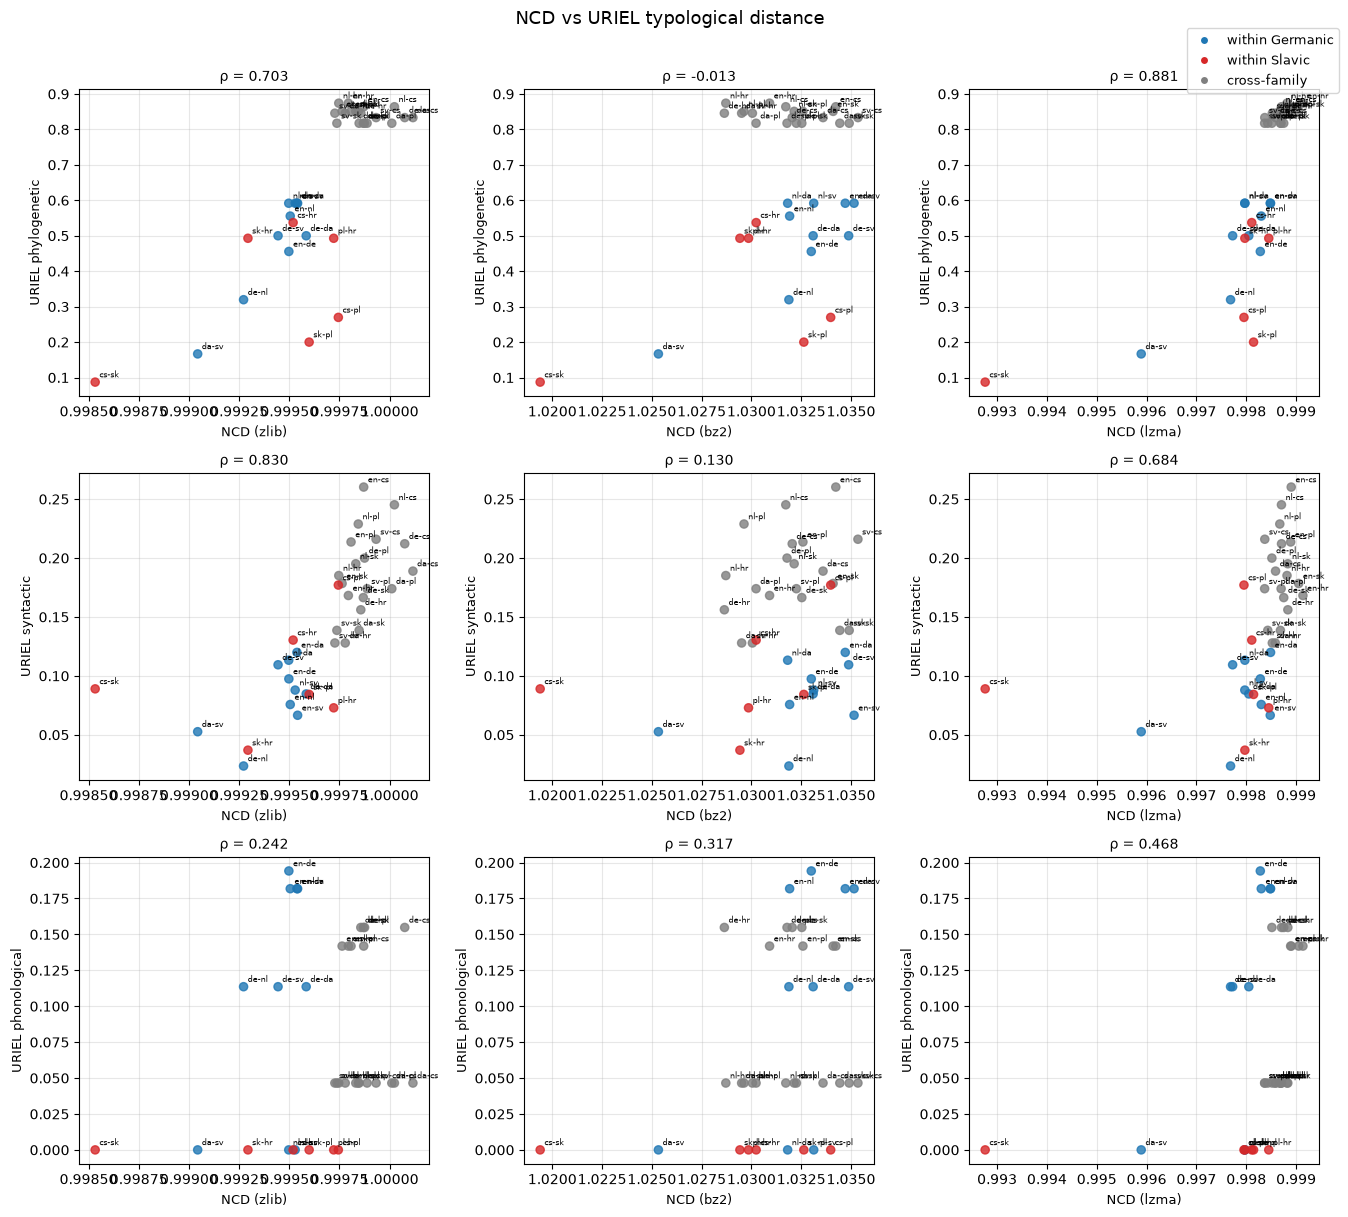

In [35]:
pair_labels = [f'{LANG_CODES[i]}-{LANG_CODES[j]}' for i, j in pairs_idx]

GERMANIC = {'en', 'de', 'nl', 'da', 'sv'}
SLAVIC   = {'cs', 'sk', 'pl', 'hr'}
def pair_color(i, j):
    a, b = LANG_CODES[i], LANG_CODES[j]
    if {a, b} <= GERMANIC: return 'tab:blue'
    if {a, b} <= SLAVIC:   return 'tab:red'
    return 'tab:grey'
colors = [pair_color(i, j) for i, j in pairs_idx]

n_uriel = len(uriel_mats)
n_comp  = len(COMPRESSORS)
fig, axes = plt.subplots(n_uriel, n_comp, figsize=(4.5 * n_comp, 4 * n_uriel), squeeze=False)

for row, (uriel_name, uriel_mat) in enumerate(uriel_mats.items()):
    u = upper_tri(uriel_mat)
    for col, comp_name in enumerate(COMPRESSORS):
        ax = axes[row, col]
        m = upper_tri(ncd_mats[comp_name])
        r, _ = spearmanr(m, u)
        ax.scatter(m, u, c=colors, s=35, alpha=0.8, zorder=2)
        for lbl, mx, uy in zip(pair_labels, m, u):
            ax.annotate(lbl, (mx, uy), fontsize=6, ha='left', va='bottom',
                        xytext=(3, 2), textcoords='offset points')
        ax.set_xlabel(f'NCD ({comp_name})', fontsize=9)
        ax.set_ylabel(f'URIEL {uriel_name}', fontsize=9)
        ax.set_title(f'ρ = {r:.3f}', fontsize=10)
        ax.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', label='within Germanic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red',  label='within Slavic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:grey', label='cross-family'),
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=9)
plt.suptitle('NCD vs URIEL typological distance', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('ncd_uriel_scatter.pdf', format='pdf', dpi=150, bbox_inches='tight')
plt.show()